In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pythtb.models import haldane
my_model = haldane(delta=0, t1=-1.0, t2=-0.15)

In [3]:
# Generate k-points
nkx, nky = 20, 20
k_pts = my_model.k_uniform_mesh([nkx, nky])

In [4]:
b_curv_na = my_model.berry_curvature(k_pts=k_pts, occ_idxs=[0], cartesian=True, non_abelian=True)
print(b_curv_na.shape)

(2, 2, 400, 1, 1)


In [5]:
print(np.allclose(b_curv_na[0,1], -b_curv_na[1,0]))  # should be True
print(np.allclose(b_curv_na[0,0], 0))  # should be True
print(np.allclose(b_curv_na[1,1], 0))  # should be True

True
True
True


In [6]:
print("Chern number band 0:", my_model.chern_number([0], nk=200))
print("Chern number band 1:", my_model.chern_number([1], nk=200))

Chern number band 0: 1.0000000000000002


Chern number band 1: -1.0000000000000002


In [7]:
b_curv = my_model.berry_curvature(k_pts=k_pts, plane=(0, 1), occ_idxs=[0], cartesian=True)
print(b_curv.shape)

(400,)


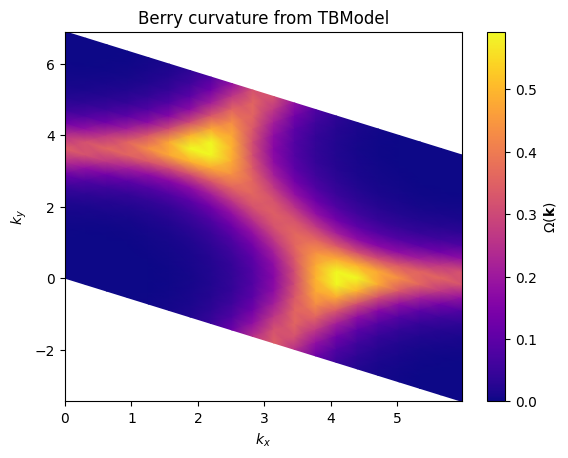

In [8]:
k_pts_sq = k_pts.reshape((nkx, nky, 2))
b_curv_sq = b_curv.reshape((nkx, nky))

recip_lat_vecs = my_model.recip_lat_vecs
mesh_Cart = k_pts_sq @ recip_lat_vecs

KX = mesh_Cart[:, :, 0]
KY = mesh_Cart[:, :, 1]

im = plt.pcolormesh(KX, KY, abs(b_curv_sq).real, cmap='plasma', shading='gouraud')

plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.colorbar(label=r'$\Omega(\mathbf{k})$')
plt.title('Berry curvature from TBModel')
plt.show()

In [9]:
g = my_model.quantum_metric(k_pts=k_pts, occ_idxs=[0], cartesian=True)
print(g.shape)

(2, 2, 400)


In [10]:
tr_g = g[0, 0] + g [1, 1]
det_g = g[0, 0]*g[1, 1] - g[0,1]*g[1,0]

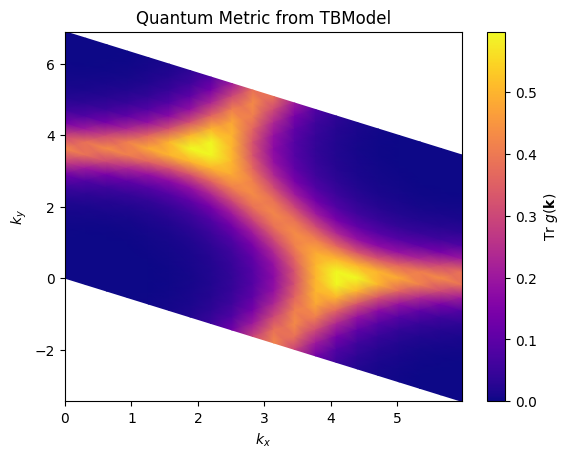

In [11]:
tr_g_sq = tr_g.reshape((nkx, nky))
im = plt.pcolormesh(KX, KY, tr_g_sq.real, cmap='plasma', shading='gouraud')

plt.xlabel(r'$k_x$')
plt.ylabel(r'$k_y$')
plt.colorbar(label=r'$\text{Tr}\ g(\mathbf{k})$')
plt.title('Quantum Metric from TBModel')
plt.show()

In [12]:
np.all(abs(b_curv).real <= tr_g.real)

np.True_

In [13]:
np.amax((1/4)*abs(b_curv).real**2 - det_g.real)

np.float64(1.3877787807814457e-17)